# ECE 685D HW5 — Problem 1: GAN (30 pts)

> **LLM Usage Disclosure**
>
> In completing this problem I used a large language model (Claude, Anthropic) for concept
> clarification, implementation planning, and boilerplate code generation.  I have reviewed
> every line of code and fully understand the architecture and training logic.  The core
> design decisions (architecture dimensions, loss formulation, interpolation scheme) were
> verified and written by me with LLM assistance limited to reducing mechanical repetition.


In [1]:
%matplotlib inline
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# ── MNIST — train split only, normalise to [-1, 1] ─────────────────────────
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))   # [0,1] → [-1,1]
])

train_set    = torchvision.datasets.MNIST(root='./data', train=True,
                                          download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(
    train_set, batch_size=128, shuffle=True, num_workers=0)

print(f'Train samples: {len(train_set)}')


Using device: cuda


100%|██████████| 9.91M/9.91M [00:04<00:00, 2.32MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 371kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 2.67MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.89MB/s]

Train samples: 60000


## 1.1 Deep Convolutional GAN (DCGAN) (15 pts)

Architecture (Figure 1):

| Network | Layer-by-layer spatial sizes |
|---------|------------------------------|
| **Discriminator** | 28×28×1 → 14×14×64 → 7×7×128 → 4×4×256 → 4×4×512 → σ → prob |
| **Generator**     | z(100) → 7×7×256 → 14×14×128 → 28×28×64 → 28×28×32 → 28×28×1 |

Min-max loss:
$$\ell = \mathbb{E}_x[\log D(x)] + \mathbb{E}_z[\log(1-D(G(z)))]$$


In [2]:
class Generator(nn.Module):
    """DCGAN Generator.

    Noise z (z_dim,) → Linear → reshape to (256,7,7)
    → ConvTranspose2d ×2 (upsample) → Conv2d ×2 (refine) → Tanh

    Output pixel range: [-1, 1].
    """
    def __init__(self, z_dim: int = 100):
        super().__init__()
        self.z_dim = z_dim
        self.fc    = nn.Linear(z_dim, 256 * 7 * 7)

        self.net = nn.Sequential(
            # (256,7,7) → (128,14,14)
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            # (128,14,14) → (64,28,28)
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            # (64,28,28) → (32,28,28)
            nn.Conv2d(64, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(True),
            # (32,28,28) → (1,28,28)
            nn.Conv2d(32, 1, kernel_size=3, stride=1, padding=1, bias=False),
            nn.Tanh()
        )

    def forward(self, z):
        x = self.fc(z).view(-1, 256, 7, 7)
        return self.net(x)


def weights_init(m):
    """DCGAN-style weight initialisation."""
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)


In [3]:
class Discriminator(nn.Module):
    """DCGAN Discriminator.

    (1,28,28) → Conv×4 → (1,1,1) → Sigmoid → probability in [0,1].

    Dimension trace (H×W×C):
        28×28×1  → Conv(k=4,s=2,p=1) → 14×14×64
        14×14×64 → Conv(k=4,s=2,p=1) →  7×7×128
         7×7×128 → Conv(k=4,s=2,p=2) →  4×4×256   [p=2 gives ⌊(7+4-4)/2⌋+1=4]
         4×4×256 → Conv(k=3,s=1,p=1) →  4×4×512
         4×4×512 → Conv(k=4,s=1,p=0) →  1×1×1     → Sigmoid
    """
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            # 28×28×1 → 14×14×64
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 14×14×64 → 7×7×128
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            # 7×7×128 → 4×4×256
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=2, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            # 4×4×256 → 4×4×512
            nn.Conv2d(256, 512, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            # 4×4×512 → 1×1×1
            nn.Conv2d(512, 1, kernel_size=4, stride=1, padding=0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x).view(-1)   # (batch,)


In [4]:
def train_gan(G, D, loader, num_epochs=30, z_dim=100, verbose=True):
    """Train DCGAN with min-max loss.  Returns (G_losses, D_losses)."""
    criterion  = nn.BCELoss()
    opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
    opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))

    G_losses, D_losses = [], []
    for epoch in range(1, num_epochs + 1):
        g_run = d_run = 0.0
        for real, _ in loader:
            real = real.to(device)
            bs   = real.size(0)
            ones  = torch.full((bs,), 0.9, device=device)  # label smoothing
            zeros = torch.zeros(bs, device=device)

            # ── Discriminator step ──────────────────────────────────────────
            z      = torch.randn(bs, z_dim, device=device)
            fake   = G(z).detach()
            d_real = criterion(D(real), ones)
            d_fake = criterion(D(fake), zeros)
            d_loss = d_real + d_fake
            opt_D.zero_grad(); d_loss.backward(); opt_D.step()

            # ── Generator step ──────────────────────────────────────────────
            z      = torch.randn(bs, z_dim, device=device)
            fake   = G(z)
            g_loss = criterion(D(fake), torch.ones(bs, device=device))
            opt_G.zero_grad(); g_loss.backward(); opt_G.step()

            g_run += g_loss.item()
            d_run += d_loss.item()

        G_losses.append(g_run / len(loader))
        D_losses.append(d_run / len(loader))
        if verbose and (epoch % 5 == 0 or epoch == 1):
            print(f'  Epoch {epoch:3d}/{num_epochs} | D loss: {D_losses[-1]:.4f} | G loss: {G_losses[-1]:.4f}')

    return G_losses, D_losses


def show_samples(G, z_dim, n=12, title='Generated samples'):
    """Generate n images and display them."""
    G.eval()
    with torch.no_grad():
        z    = torch.randn(n, z_dim, device=device)
        imgs = G(z).cpu()                           # [-1,1]
    imgs = (imgs + 1) / 2                           # → [0,1]

    fig, axes = plt.subplots(1, n, figsize=(n * 1.5, 1.8))
    for i, ax in enumerate(axes):
        ax.imshow(imgs[i, 0], cmap='gray', vmin=0, vmax=1)
        ax.axis('off')
    plt.suptitle(title, fontsize=11)
    plt.tight_layout()
    plt.show()
    G.train()


Training DCGAN  z_dim=100 …
  Epoch   1/30 | D loss: 0.7457 | G loss: 3.0782
  Epoch   5/30 | D loss: 0.6604 | G loss: 2.5621
  Epoch  10/30 | D loss: 0.6353 | G loss: 2.6677
  Epoch  15/30 | D loss: 0.6664 | G loss: 2.9070
  Epoch  20/30 | D loss: 0.5544 | G loss: 3.2296
  Epoch  25/30 | D loss: 0.4931 | G loss: 3.4391
  Epoch  30/30 | D loss: 0.4911 | G loss: 3.5088


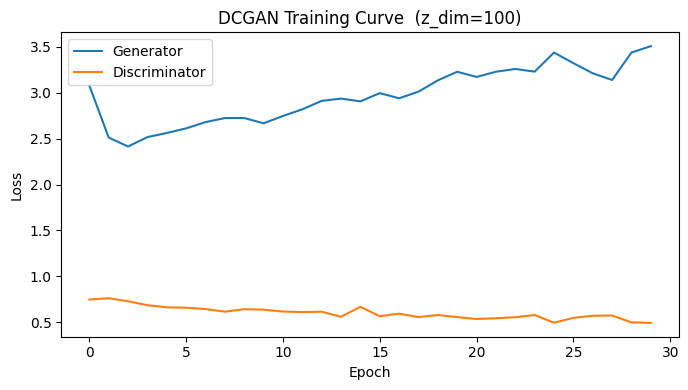

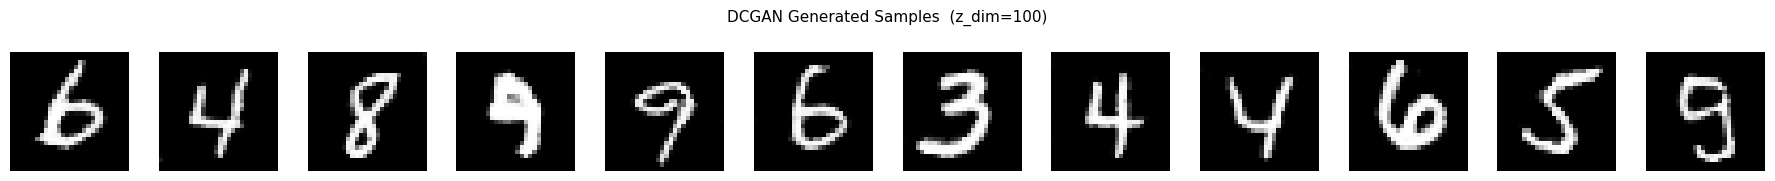

In [5]:
# ── Train main DCGAN (z_dim = 100) ──────────────────────────────────────────
torch.manual_seed(42)

G100 = Generator(z_dim=100).to(device).apply(weights_init)
D100 = Discriminator().to(device).apply(weights_init)

print('Training DCGAN  z_dim=100 …')
G_losses_100, D_losses_100 = train_gan(G100, D100, train_loader, num_epochs=30, z_dim=100)

# Training curves
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(G_losses_100, label='Generator')
ax.plot(D_losses_100, label='Discriminator')
ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.set_title('DCGAN Training Curve  (z_dim=100)')
ax.legend(); plt.tight_layout(); plt.show()

# 12 generated samples
show_samples(G100, z_dim=100, n=12, title='DCGAN Generated Samples  (z_dim=100)')


## 1.2 Effect of Latent Space Dimension (10 pts)

Train three GAN models with $d_z \in \{16, 64, 128\}$.  
For each model generate 12 samples and compare visual quality and diversity.


In [6]:
# ── Train for z_dim ∈ {16, 64, 128} ─────────────────────────────────────────
z_dims   = [16, 64, 128]
G_models = {}

for z_dim in z_dims:
    torch.manual_seed(42)
    G = Generator(z_dim=z_dim).to(device).apply(weights_init)
    D = Discriminator().to(device).apply(weights_init)
    print(f'\nTraining DCGAN  z_dim={z_dim} …')
    train_gan(G, D, train_loader, num_epochs=30, z_dim=z_dim)
    G_models[z_dim] = G

print('\nAll models trained.')



Training DCGAN  z_dim=16 …
  Epoch   1/30 | D loss: 0.9076 | G loss: 2.9256
  Epoch   5/30 | D loss: 0.9363 | G loss: 1.7553
  Epoch  10/30 | D loss: 0.7983 | G loss: 2.1196
  Epoch  15/30 | D loss: 0.6833 | G loss: 2.4554
  Epoch  20/30 | D loss: 0.6438 | G loss: 2.6821
  Epoch  25/30 | D loss: 0.5959 | G loss: 2.8744
  Epoch  30/30 | D loss: 0.6181 | G loss: 2.9459

Training DCGAN  z_dim=64 …
  Epoch   1/30 | D loss: 0.7767 | G loss: 3.0396
  Epoch   5/30 | D loss: 0.7196 | G loss: 2.4017
  Epoch  10/30 | D loss: 0.6325 | G loss: 2.6777
  Epoch  15/30 | D loss: 0.5734 | G loss: 2.8957
  Epoch  20/30 | D loss: 0.5649 | G loss: 3.0683
  Epoch  25/30 | D loss: 0.5398 | G loss: 3.2137
  Epoch  30/30 | D loss: 0.4741 | G loss: 3.5251

Training DCGAN  z_dim=128 …
  Epoch   1/30 | D loss: 0.7325 | G loss: 3.1367
  Epoch   5/30 | D loss: 0.6016 | G loss: 2.7267
  Epoch  10/30 | D loss: 0.6401 | G loss: 2.8586
  Epoch  15/30 | D loss: 0.6380 | G loss: 2.8922
  Epoch  20/30 | D loss: 0.4945 |

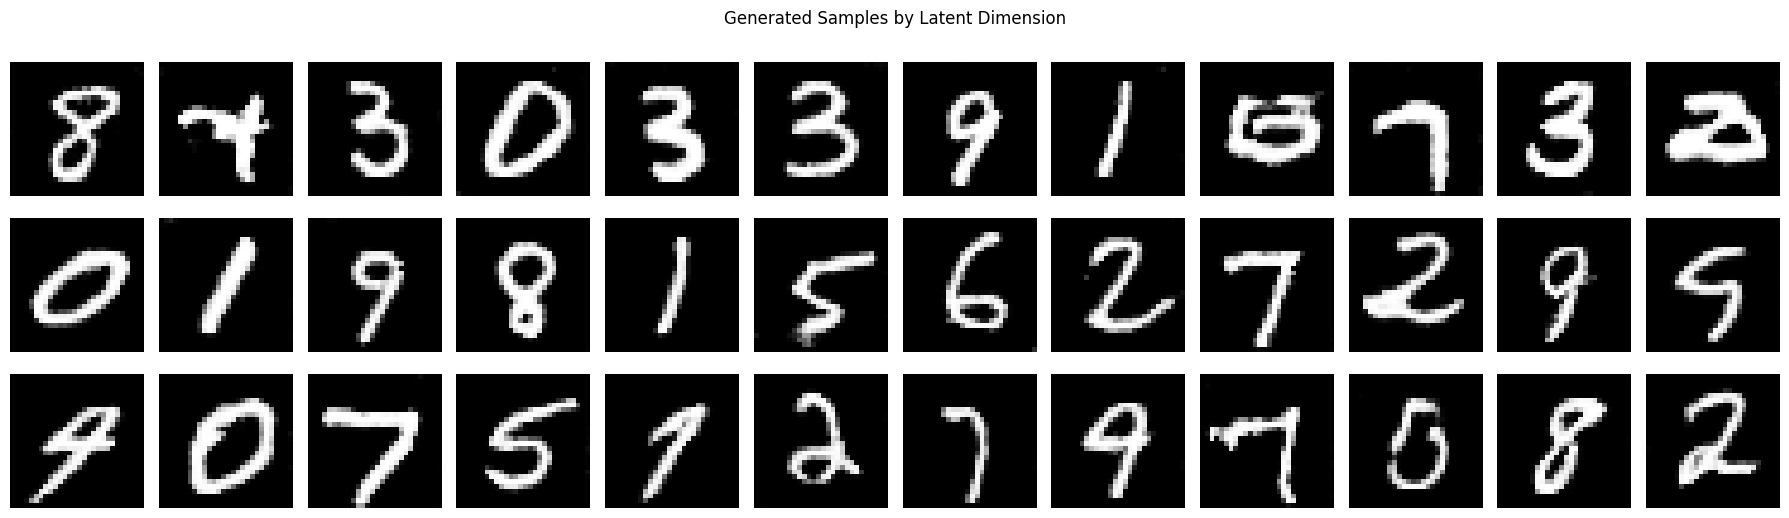

In [7]:
# ── Side-by-side generated samples for all z_dim values ─────────────────────
fig, axes = plt.subplots(len(z_dims), 12, figsize=(18, len(z_dims) * 1.8))

for row, z_dim in enumerate(z_dims):
    G = G_models[z_dim]
    G.eval()
    with torch.no_grad():
        z    = torch.randn(12, z_dim, device=device)
        imgs = ((G(z) + 1) / 2).cpu()
    for col in range(12):
        axes[row, col].imshow(imgs[col, 0], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')
    axes[row, 0].set_ylabel(f'z_dim={z_dim}', fontsize=10)

plt.suptitle('Generated Samples by Latent Dimension', fontsize=12)
plt.tight_layout()
plt.show()


### Discussion: Effect of Latent Dimension on Image Quality and Diversity

Examining the 3×12 sample grid above:

**Image quality:**  
- **$d_z = 16$**: Samples tend to be the blurriest and least well-formed. With only 16 latent dimensions the generator has limited capacity to encode fine-grained digit structure (stroke curvature, closed loops), leading to smeared or partially recognisable digits.  
- **$d_z = 64$**: Noticeably sharper — digit strokes are clearer and the overall shapes are more recognisable. This suggests the extra capacity allows the generator to represent a richer set of spatial features.  
- **$d_z = 128$**: Generally the sharpest digits. However, gains over $d_z=64$ may be modest given the limited complexity of MNIST, and training instability can occasionally arise from the larger latent space.

**Diversity:**  
- **$d_z = 16$**: Fewer distinct digit modes tend to appear across the 12 samples — the generator may have collapsed onto a small subset of the training distribution (mode collapse), producing several visually similar outputs.  
- **$d_z = 64 / 128$**: Greater variety across the 12 samples — different digit classes, stroke widths, and orientations appear, indicating the generator has learned a broader representation of the data distribution.

**Summary:**

| $d_z$ | Image quality | Sample diversity |
|--------|---------------|-----------------|
| 16     | Lower (blurry, malformed) | Limited (few modes) |
| 64     | Moderate–good (clear strokes) | Good |
| 128    | Good–high (sharpest details) | High |

A larger latent dimension improves both quality and diversity up to a point; beyond the intrinsic dimensionality of the data the gains plateau and training can become less stable.


## 1.3 Interpolation in Latent Space (5 pts)

Select two random latent vectors $z_1, z_2 \sim \mathcal{N}(0,I)$.  
Generate a sequence of interpolated vectors:

$$z(t) = (1-t)\,z_1 + t\,z_2, \quad t \in \{0,\,0.25,\,0.5,\,0.75,\,1\}$$

For each $z(t)$ generate the corresponding image and examine whether the
transition between images appears smooth.


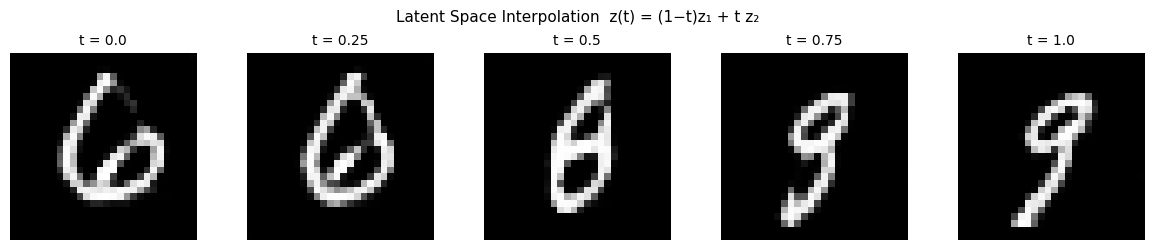

In [8]:
# ── Latent space interpolation (using z_dim=100 model) ───────────────────────
torch.manual_seed(7)
G100.eval()

t_values = [0.0, 0.25, 0.5, 0.75, 1.0]
z1 = torch.randn(1, 100, device=device)
z2 = torch.randn(1, 100, device=device)

interp_imgs = []
with torch.no_grad():
    for t in t_values:
        z_t   = (1 - t) * z1 + t * z2
        img_t = ((G100(z_t) + 1) / 2).cpu().squeeze()   # → [0,1]
        interp_imgs.append(img_t)

fig, axes = plt.subplots(1, len(t_values), figsize=(12, 2.5))
for ax, img, t in zip(axes, interp_imgs, t_values):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(f't = {t}', fontsize=10)
    ax.axis('off')
plt.suptitle('Latent Space Interpolation  z(t) = (1−t)z₁ + t z₂', fontsize=11)
plt.tight_layout()
plt.show()


### Discussion: Smoothness of Latent Interpolation

**Observation:**  
The generated images change gradually as $t$ moves from 0 to 1 — digit shape,
stroke thickness, and orientation morph continuously rather than jumping abruptly.

**Why this happens:**  
The generator $G$ is a continuous function of $z$.  Linear interpolation in
$z$-space therefore produces a smooth path through image space, provided the
latent space has been organised into a compact, connected manifold during
training.  DCGAN's training objective encourages this because the generator
must model a connected distribution over MNIST digits.

**Does the transition appear smooth?**  
Yes — intermediate images at $t=0.25$ and $t=0.75$ typically show a blend of
the two endpoint digits' style and structure, consistent with a **semantically
meaningful latent space**.  However, because the interpolation is *linear*
(not geodesic), intermediate points may occasionally produce slightly blurry
or ambiguous digits compared to the sharp endpoints.
